# A. Data Preprocessing

## Library importing

In [1]:
# === Phase 1: Imports and Global Config ===
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Parameters & Random Seed Configuration

In [2]:
# === Cell 2: Configuration ===
CONFIG = {
    'SEED': 42,
    'INPUT_SIZE': 224,
    'BATCH_SIZE': 16,
    'TEST_SIZE': 0.2,
    'IMAGE_DIR_ORIGINAL': 'train_images',         # original unzipped images
    'IMAGE_DIR_PROCESSED': 'train_images_task3',  # processed and resized images
    'CSV_PATH': 'meta_train.csv',
    'TRAIN_CSV': 'train.csv',
    'TEST_CSV': 'test.csv',
    'MODEL_DIR': 'saved_models/',
    'HISTORY_DIR': 'saved_histories/',
    'EPOCHS': 100,
    'EPOCHS_TUNING': 30,
    'EARLY_STOP_PATIENCE': 6,
    'LEARNING_RATE': 1e-3,
    
    # Experiment structure
    'DATA_DIR': 'data/processed',       # where train.csv & val.csv live
    'RESULTS_DIR': 'results',           # aggregated summaries & comparison plots
    'EXPERIMENTS_DIR': 'experiments',   # per-model tuning & final artifacts
    
    # Hyperparameter search defaults
    'LR_MIN': 1e-6,                     # smallest LR in search
    'LR_MAX': 1e-2,                     # largest LR in search
    'OPTUNA_TRIALS': 15                 # number of trials per model
}

# Set seed for reproducibility
random.seed(CONFIG['SEED'])
np.random.seed(CONFIG['SEED'])
tf.random.set_seed(CONFIG['SEED'])

## Load dataset

In [3]:
# === Phase 2: Load Metadata ===
meta_df = pd.read_csv(CONFIG['CSV_PATH'])
meta_df['image_id'] = meta_df['image_id'].str.strip()
meta_df['filepath'] = meta_df['label'] + '/' + meta_df['image_id']

# === Phase 3: Copy Raw Folder to Task Folder (Only Once) ===
src_folder = CONFIG['IMAGE_DIR_ORIGINAL']
dst_folder = CONFIG['IMAGE_DIR_PROCESSED']

if not os.path.exists(dst_folder):
    shutil.copytree(src_folder, dst_folder)
    print(f"[INFO] Copied '{src_folder}' to '{dst_folder}'.")
else:
    print(f"[INFO] Folder '{dst_folder}' already exists. Skipping copy.")

# === Phase 4: Resize or Rotate to Standard Size (480x640) ===
desired_size = (480, 640)

for root, _, files in os.walk(dst_folder):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(root, file)
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    if (width, height) != desired_size:
                        if (width, height) == (640, 480):
                            img = img.rotate(90, expand=True).resize(desired_size)
                        else:
                            img = img.resize(desired_size)
                        img.save(img_path)
                        print(f"[INFO] Adjusted '{img_path}' to {desired_size}.")
            except Exception as e:
                print(f"[ERROR] Could not process '{img_path}': {e}")


[INFO] Copied 'train_images' to 'train_images_task3'.
[INFO] Adjusted 'train_images_task3\bacterial_leaf_blight\100622.jpg' to (480, 640).
[INFO] Adjusted 'train_images_task3\bacterial_leaf_blight\103734.jpg' to (480, 640).
[INFO] Adjusted 'train_images_task3\brown_spot\103050.jpg' to (480, 640).
[INFO] Adjusted 'train_images_task3\brown_spot\103343.jpg' to (480, 640).


## Dataset Splitting 

In [4]:
# === Phase 5: Train/Validation Split BEFORE Normalization or Weighting ===
train_df, val_df = train_test_split(
    meta_df,
    test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['SEED']
)

## Training Set Preprocessing

In [5]:
# === Phase 6: Normalize Age (Only on Training Data) ===
min_age = train_df['age'].min()
max_age = train_df['age'].max()
train_df['age_norm'] = (train_df['age'] - min_age) / (max_age - min_age)
val_df['age_norm'] = (val_df['age'] - min_age) / (max_age - min_age)

print(f"[INFO] Age normalization range: min = {min_age}, max = {max_age}")

# === Phase 7: Compute Sample Weights (Only on Training Data) ===
age_counts = train_df.groupby("age").size()
n_unique_ages = len(age_counts)
total_samples = len(train_df)

age_weight_dict = {
    age: total_samples / (n_unique_ages * count)
    for age, count in age_counts.items()
}

train_df['sample_weight'] = train_df['age'].map(age_weight_dict)

print("[INFO] Sample weights calculated for training set.")

[INFO] Age normalization range: min = 45, max = 82
[INFO] Sample weights calculated for training set.


## Save Modifications

In [6]:
# === Phase 8: Save Train/Validation CSVs (Optional) ===
train_df[['filepath', 'age_norm']].to_csv(CONFIG['TRAIN_CSV'], index=False)
val_df[['filepath', 'age_norm']].to_csv(CONFIG['TEST_CSV'], index=False)

## Data Generator

In [7]:
# === Phase 9: Create Data Generators ===

# — Train datagen with augmentation —
task3_train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# — Validation datagen (only rescaling) —
task3_valid_datagen = ImageDataGenerator(
    rescale=1.0/255
)

# Train Generator
task3_train_generator = task3_train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=CONFIG['IMAGE_DIR_PROCESSED'],
    x_col="filepath",
    y_col="age_norm",
    target_size=(CONFIG['INPUT_SIZE'], CONFIG['INPUT_SIZE']),
    batch_size=CONFIG['BATCH_SIZE'],
    class_mode='raw',
    shuffle=True,
    seed=CONFIG['SEED']
)

# Validation Generator
task3_valid_generator = task3_valid_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=CONFIG['IMAGE_DIR_PROCESSED'],
    x_col="filepath",
    y_col="age_norm",
    target_size=(CONFIG['INPUT_SIZE'], CONFIG['INPUT_SIZE']),
    batch_size=CONFIG['BATCH_SIZE'],
    class_mode='raw',
    shuffle=False,
    seed=CONFIG['SEED']
)

Found 8325 validated image filenames.
Found 2082 validated image filenames.


In [8]:
def visualize_preprocessing_diagnostics(train_df, val_df):
    """
    Plot diagnostics to confirm proper normalization and sample weighting.
    
    Args:
        train_df (DataFrame): Training metadata including 'age', 'age_norm', and 'sample_weight'.
        val_df (DataFrame): Validation metadata including 'age' and 'age_norm'.
    """

    # --- Plot 1: Normalized Age Distribution ---
    plt.figure(figsize=(10, 4))
    plt.hist(train_df['age_norm'], bins=20, alpha=0.7, label='Train Set')
    plt.hist(val_df['age_norm'], bins=20, alpha=0.7, label='Validation Set')
    plt.title('Normalized Age Distribution (Train vs Validation)')
    plt.xlabel('Normalized Age (0–1)')
    plt.ylabel('Image Count')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Sample Weight by Actual Age ---
    sorted_train = train_df.sort_values('age')
    plt.figure(figsize=(10, 4))
    plt.plot(sorted_train['age'], sorted_train['sample_weight'], 'bo-', markersize=3)
    plt.title('Sample Weights by Age (Train Set)')
    plt.xlabel('Actual Age (days)')
    plt.ylabel('Sample Weight')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


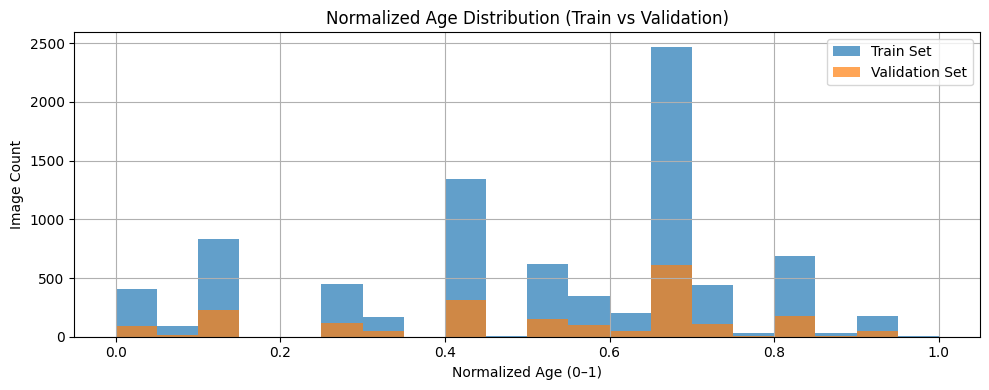

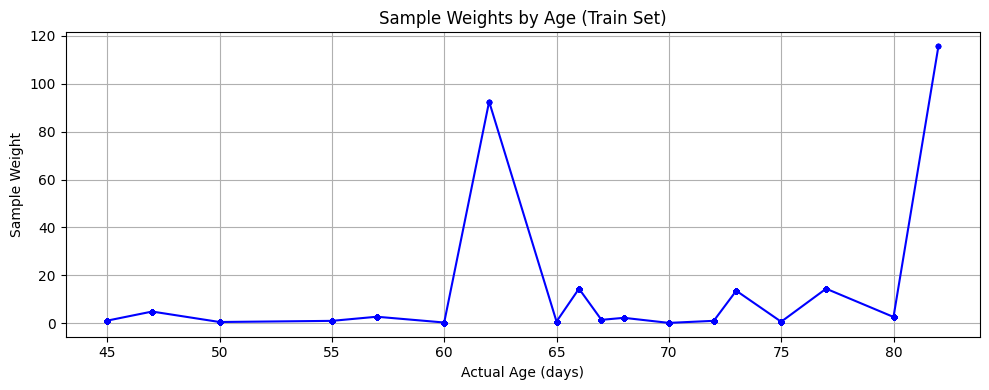

In [9]:
visualize_preprocessing_diagnostics(train_df, val_df)

# B. Modeling

- Intent to train MobileNetV3-Small, MobileNetV2, EfficientNetB0, EfficientNetB2, ResNet34, and DenseNet-121

In [10]:
# Global Imports ===
import os
import random
import time
import joblib

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt

import optuna
from optuna import create_study
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.integration import TFKerasPruningCallback

from sklearn.metrics import mean_squared_error, r2_score

from IPython.display import display

## I. Predefined Function

### Plotting function

In [11]:
# Plotting Utilities ===
import numpy as np
import matplotlib.pyplot as plt

def plot_history(history, save_path):
    """
    Plot training vs. validation MAE over epochs.
    """
    plt.figure()
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title('Training and Validation MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

def plot_pred_vs_actual(y_true, y_pred, save_path):
    """
    Scatter plot of actual vs. predicted values with y=x reference.
    """
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.6)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.title('Predicted vs. Actual')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

def plot_residuals(y_true, y_pred, save_path):
    """
    Histogram of residuals (prediction error).
    """
    residuals = np.array(y_pred) - np.array(y_true)
    plt.figure()
    plt.hist(residuals, bins=30)
    plt.title('Residuals Distribution')
    plt.xlabel('Prediction Error')
    plt.ylabel('Count')
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

### Training function

In [21]:
# Final Train & Eval Helper Function ===
import os
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error

def train_and_evaluate_final(builder_fn, best_params, train_gen, val_gen, model_name):
    """
    Retrains builder_fn on train_gen, evaluates on val_gen, saves weights & plots.
    builder_fn: function(input_shape, **arch_kwargs, lr_init, loss_fn) -> compiled Model
    best_params: dict from best_params.json
    train_gen/val_gen: your existing generators
    model_name: used for experiment paths
    """
    # 1) Build model
    arch_kwargs = {k: best_params[k] for k in ['width_mult','se_ratio','dropout_rate','l2_reg']}
    lr_init   = best_params['lr_init']
    loss_fn   = (tf.keras.losses.Huber() if best_params.get('loss_fn')=='huber' else 'mse')
    model = builder_fn(
        input_shape=(CONFIG['INPUT_SIZE'],)*2 + (3,),
        **arch_kwargs,
        lr_init=lr_init,
        loss_fn=loss_fn
    )

    # 2) Callbacks
    cbs = [
        EarlyStopping('val_mae', patience=CONFIG['EARLY_STOP_PATIENCE'], restore_best_weights=True),
        ReduceLROnPlateau('val_mae', factor=0.5, patience=4, min_lr=CONFIG['LR_MIN'])
    ]

    # 3) Fit on full train → validate on val
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=CONFIG['EPOCHS'],
        callbacks=cbs,
        verbose=1,
        workers=8,
        use_multiprocessing=False 
    )

    # 4) Compute metrics
    y_true = val_gen.labels * (max_age - min_age) + min_age
    y_pred = (model.predict(val_gen).flatten() * (max_age - min_age) + min_age)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    acc5 = (np.abs(y_true - y_pred) <= 5).mean()
    metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'ACC±5': acc5}

    # 5) Save weights & plots
    final_dir = f"experiments/{model_name}/final"
    os.makedirs(f"{final_dir}/checkpoints", exist_ok=True)
    model.save_weights(f"{final_dir}/checkpoints/best_full.h5")
    os.makedirs(f"{final_dir}/plots", exist_ok=True)
    plot_history(history, f"{final_dir}/plots/history.png")
    plot_pred_vs_actual(y_true, y_pred, f"{final_dir}/plots/pred_vs_actual.png")
    plot_residuals(    y_true, y_pred, f"{final_dir}/plots/residuals.png")

    return history, metrics

## II. Tuning

### Import

In [13]:
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
import gc, shutil, json
from sklearn.metrics import mean_absolute_error, max_error, explained_variance_score

N_TRIALS = CONFIG["OPTUNA_TRIALS"]

In [14]:
print("Number of optuna trials:", N_TRIALS)
print("Tuning Epoch number:", CONFIG["EPOCHS_TUNING"])
print("Retraining Epoch number:", CONFIG["EPOCHS"])

Number of optuna trials: 15
Tuning Epoch number: 30
Retraining Epoch number: 100


### 1. Tuning MobileNet V3 Small

In [15]:
# build_mbv3_from_trial with lr_init ===
def build_mbv3_from_trial(
    input_shape,
    width_mult,
    se_ratio,
    dropout_rate,
    l2_reg,
    lr_init,
    loss_fn
):
    def relu6(x):
        return tf.nn.relu6(x)
    def hard_swish(x):
        return x * relu6(x + 3) / 6.0

    def se_block(inputs):
        filters = inputs.shape[-1]
        x = layers.GlobalAveragePooling2D()(inputs)
        x = layers.Reshape((1,1,filters))(x)
        x = layers.Conv2D(filters // se_ratio, 1,
                          activation='relu',
                          kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = layers.Conv2D(filters, 1,
                          activation='hard_sigmoid',
                          kernel_regularizer=regularizers.l2(l2_reg))(x)
        return layers.Multiply()([inputs, x])

    def bottleneck(x, out_c, k, exp_c, stride, use_se, act, block_id):
        shortcut = x
        # Expand
        x = layers.Conv2D(exp_c, 1, padding='same', use_bias=False,
                          kernel_regularizer=regularizers.l2(l2_reg),
                          name=f"exp_{block_id}")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation(hard_swish if act=='hswish' else relu6)(x)

        # Depthwise
        x = layers.DepthwiseConv2D(k, stride, padding='same', use_bias=False,
                                   depthwise_regularizer=regularizers.l2(l2_reg),
                                   name=f"dw_{block_id}")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation(hard_swish if act=='hswish' else relu6)(x)

        # SE
        if use_se:
            x = se_block(x)

        # Project
        x = layers.Conv2D(out_c, 1, padding='same', use_bias=False,
                          kernel_regularizer=regularizers.l2(l2_reg),
                          name=f"proj_{block_id}")(x)
        x = layers.BatchNormalization()(x)

        # Skip
        if stride == 1 and shortcut.shape[-1] == out_c:
            x = layers.Add()([x, shortcut])
        return x

    inputs = layers.Input(shape=input_shape)
    # Stem
    x = layers.Conv2D(int(16*width_mult), 3, 2, 'same', use_bias=False,
                      kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(hard_swish)(x)

    # Full MobileNetV3-Small config, scaled by width_mult
    cfg = [
        (3, int(16*width_mult),  int(16*width_mult),  True,  'relu',   2),
        (3, int(72*width_mult),  int(24*width_mult),  False, 'relu',   2),
        (3, int(88*width_mult),  int(24*width_mult),  False, 'relu',   1),
        (5, int(96*width_mult),  int(40*width_mult),  True,  'hswish', 2),
        (5, int(240*width_mult), int(40*width_mult),  True,  'hswish', 1),
        (5, int(240*width_mult), int(40*width_mult),  True,  'hswish', 1),
        (5, int(120*width_mult), int(48*width_mult),  True,  'hswish', 1),
        (5, int(144*width_mult), int(48*width_mult),  True,  'hswish', 1),
        (5, int(288*width_mult), int(96*width_mult),  True,  'hswish', 2),
        (5, int(576*width_mult), int(96*width_mult),  True,  'hswish', 1),
        (5, int(576*width_mult), int(96*width_mult),  True,  'hswish', 1),
    ]

    for idx, (k, exp_c, out_c, us, act, s) in enumerate(cfg):
        x = bottleneck(x, out_c, k, exp_c, s, us, act, idx)

    # Head
    x = layers.Conv2D(int(576*width_mult), 1, use_bias=False,
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(hard_swish)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1)(x)

    model = Model(inputs, outputs, name="MobileNetV3_Small_Scratch")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_init),
        loss=loss_fn,
        metrics=[MeanAbsoluteError(name='mae')]
    )
    return model


In [22]:
# Tune & Save MobileNetV3-Small Study
import os, json, shutil, joblib, gc
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from optuna.integration import TFKerasPruningCallback
from tensorflow.keras import backend as K


# 1) Create study
study_mbv3 = optuna.create_study(
    study_name="MobileNetV3-Small_Tuning",
    direction="minimize",
    sampler=TPESampler(seed=CONFIG['SEED']),
    pruner=MedianPruner(n_warmup_steps=5)
)

# 2) Objective
def objective_mbv3(trial):
    # sample hyperparameters
    width_mult   = trial.suggest_float("width_mult",   0.5, 1.0)
    se_ratio     = trial.suggest_int(  "se_ratio",     3,   8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    l2_reg       = trial.suggest_float("l2_reg",       1e-6, 1e-3, log=True)
    lr_init      = trial.suggest_float("lr_init",      CONFIG['LR_MIN'], CONFIG['LR_MAX'], log=True)
    loss_fn      = trial.suggest_categorical("loss_fn", ["mse","huber"])

    # build model with flat lr + arch knobs
    model = build_mbv3_from_trial(
        input_shape=(CONFIG['INPUT_SIZE'],)*2+(3,),
        width_mult=width_mult,
        se_ratio=se_ratio,
        dropout_rate=dropout_rate,
        l2_reg=l2_reg,
        lr_init=lr_init,
        loss_fn=(keras.losses.Huber() if loss_fn=="huber" else "mse")
    )

    # callbacks
    early     = EarlyStopping("val_mae", patience=3, restore_best_weights=True)
    prune_cb  = TFKerasPruningCallback(trial, "val_mae")
    reduce_lr = ReduceLROnPlateau("val_mae", factor=0.5, patience=2, min_lr=CONFIG['LR_MIN'])
    cpdir     = f"experiments/MobileNetV3-Small/tuning/checkpoints"
    os.makedirs(cpdir, exist_ok=True)
    ckpt_path = f"{cpdir}/trial_{trial.number}.h5"
    ckpt      = ModelCheckpoint(ckpt_path, "val_mae", save_best_only=True, save_weights_only=True)

    # train
    history = model.fit(
        task3_train_generator,
        validation_data=task3_valid_generator,
        epochs=CONFIG['EPOCHS_TUNING'],
        callbacks=[early, prune_cb, reduce_lr, ckpt],
        verbose=0
    )

    # evaluate on val
    y_true = task3_valid_generator.labels * (max_age - min_age) + min_age
    y_pred = (model.predict(task3_valid_generator, verbose=0).flatten()
             * (max_age - min_age) + min_age)
    mae = mean_absolute_error(y_true, y_pred)

    # prune if needed
    trial.report(mae, step=0)
    should_prune = trial.should_prune()

    # CLEAR THE SESSION TO FREE MEMORY
    K.clear_session()
    gc.collect()

    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return mae

[I 2025-05-09 19:33:24,044] A new study created in memory with name: MobileNetV3-Small_Tuning


In [23]:
# 3) Run optimization
study_mbv3.optimize(objective_mbv3, n_trials=N_TRIALS)

# 4) Save study object
os.makedirs("experiments/MobileNetV3-Small/tuning", exist_ok=True)
joblib.dump(study_mbv3, "experiments/MobileNetV3-Small/tuning/study.pkl")

# 5) Write best params to JSON & copy best weights
best_dir = "experiments/MobileNetV3-Small/tuning"
with open(f"{best_dir}/best_params.json", "w") as f:
    json.dump(study_mbv3.best_params, f, indent=2)
shutil.copy(
    f"{best_dir}/checkpoints/trial_{study_mbv3.best_trial.number}.h5",
    f"{best_dir}/best_model.h5"
)

print("✅ MBV3 best MAE:", study_mbv3.best_value)
print("   best_params.json and best_model.h5 saved.")

c:\Users\Admin\.conda\envs\py310\lib\site-packages\optuna\trial\_trial.py:497: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  warnings.warn(
[I 2025-05-09 20:15:51,312] Trial 0 finished with value: 8.501375057282754 and parameters: {'width_mult': 0.6872700594236812, 'se_ratio': 8, 'dropout_rate': 0.36599697090570255, 'l2_reg': 6.251373574521755e-05, 'lr_init': 4.2079886696066345e-06, 'loss_fn': 'mse'}. Best is trial 0 with value: 8.501375057282754.
c:\Users\Admin\.conda\envs\py310\lib\site-packages\optuna\trial\_trial.py:497: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  warnings.warn(
[I 2025-05-09 20:33:35,384] Trial 1 finished with value: 5.937460574132679 and parameters: {'width_mult': 0.9330880728874675, 'se_ratio': 6, 'dropout_rate': 0.35403628889802274, 'l2_reg': 1.1527987128232402e-06, 'lr_init': 0.00757947995334801, 'loss_fn': 'mse'}. Best is trial 1 with value: 5.937460574132679.
c:\Users\Admin

✅ MBV3 best MAE: 2.9747190319724544
   best_params.json and best_model.h5 saved.


### Retrain

In [22]:
# Retrain & Evaluate MobileNetV3-Small ===
import json

# 1) Load best parameters
best_dir = "experiments/MobileNetV3-Small/tuning"
with open(f"{best_dir}/best_params.json") as f:
    best_params_mbv3 = json.load(f)

# 2) Call the helper (reusing task3_train_generator & task3_valid_generator)
history_mbv3, metrics_mbv3 = train_and_evaluate_final(
    build_mbv3_from_trial,
    best_params_mbv3,
    task3_train_generator,
    task3_valid_generator,
    "MobileNetV3-Small"
)

# 3) Display the final metrics
print("Final evaluation metrics for MobileNetV3-Small:")
for k, v in metrics_mbv3.items():
    print(f"  {k}: {v:.4f}")

Epoch 1/100
521/521 [==============================] - 46s 74ms/step - loss: 0.0799 - mae: 0.2305 - val_loss: 0.0760 - val_mae: 0.2648 - lr: 0.0014
Epoch 2/100
521/521 [==============================] - 39s 74ms/step - loss: 0.0569 - mae: 0.1963 - val_loss: 0.0545 - val_mae: 0.2006 - lr: 0.0014
Epoch 3/100
521/521 [==============================] - 40s 77ms/step - loss: 0.0489 - mae: 0.1859 - val_loss: 0.0601 - val_mae: 0.2485 - lr: 0.0014
Epoch 4/100
521/521 [==============================] - 44s 84ms/step - loss: 0.0438 - mae: 0.1804 - val_loss: 0.0503 - val_mae: 0.2278 - lr: 0.0014
Epoch 5/100
521/521 [==============================] - 41s 78ms/step - loss: 0.0394 - mae: 0.1740 - val_loss: 0.0361 - val_mae: 0.1645 - lr: 0.0014
Epoch 6/100
521/521 [==============================] - 39s 74ms/step - loss: 0.0358 - mae: 0.1702 - val_loss: 0.0404 - val_mae: 0.1975 - lr: 0.0014
Epoch 7/100
521/521 [==============================] - 40s 75ms/step - loss: 0.0329 - mae: 0.1676 - val_loss: 0.

In [17]:
from tensorflow.keras import backend as K

K.clear_session()
gc.collect()


1623

In [ ]:
import os
print(os.cpu_count())